# 🛡️ NSL-KDD — Algoritmos Clássicos de Machine Learning

**Objetivo:** Detectar intrusões de rede usando algoritmos clássicos de ML e comparar seu desempenho.

**Dataset:** NSL-KDD — versão refinada do KDD Cup 1999, benchmark padrão para Sistemas de Detecção de Intrusão (IDS).

---
**Algoritmos avaliados:**
| Algoritmo | Tipo |
|---|---|
| Naive Bayes | Probabilístico |
| Decision Tree | Baseado em regras |
| K-Nearest Neighbors | Baseado em instância |
| Random Forest | Ensemble |
| Support Vector Machine | Margem máxima |


## 📦 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 📂 2. Carregamento do Dataset NSL-KDD

In [2]:
# Nomes das features do NSL-KDD
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

TRAIN_PATH = '../data/KDDTrain+.txt'
TEST_PATH  = '../data/KDDTest+.txt'

try:
    df_train = pd.read_csv(TRAIN_PATH, header=None, names=FEATURE_NAMES)
    df_test  = pd.read_csv(TEST_PATH,  header=None, names=FEATURE_NAMES)
    print(f'✅ Dados carregados! Treino: {df_train.shape} | Teste: {df_test.shape}')
except FileNotFoundError:
    print('⚠️  Arquivo não encontrado. Baixando dataset automaticamente...')
    import subprocess
    subprocess.run(['bash', '../data/download_data.sh'], check=True)
    df_train = pd.read_csv(TRAIN_PATH, header=None, names=FEATURE_NAMES)
    df_test  = pd.read_csv(TEST_PATH,  header=None, names=FEATURE_NAMES)
    print(f'✅ Dados carregados! Treino: {df_train.shape} | Teste: {df_test.shape}')

✅ Dados carregados! Treino: (125973, 43) | Teste: (22544, 43)


## 🔍 3. Análise Exploratória de Dados (EDA)

In [3]:
print('=== Primeiras linhas do dataset ===')
df_train.head()

=== Primeiras linhas do dataset ===


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
print('=== Informações gerais ===')
df_train.info()

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              12

In [5]:
print('=== Estatísticas Descritivas ===')
df_train.describe()

=== Estatísticas Descritivas ===


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


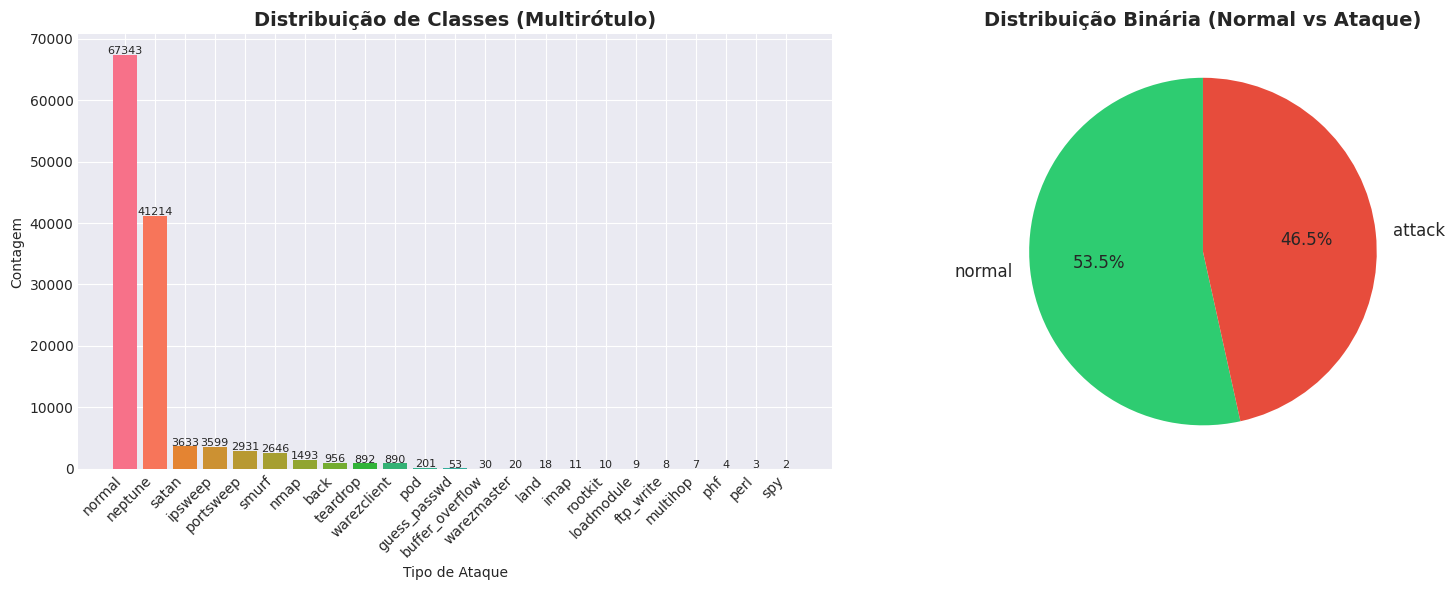


Distribuição binária:
binary_label
normal    67343
attack    58630
Name: count, dtype: int64


In [6]:
# Distribuição de classes (multi-classe)
label_counts = df_train['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
colors = sns.color_palette('husl', len(label_counts))
axes[0].bar(range(len(label_counts)), label_counts.values, color=colors)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right')
axes[0].set_title('Distribuição de Classes (Multirótulo)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Ataque')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=8)

# Binário: normal vs ataque
df_train['binary_label'] = df_train['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
binary_counts = df_train['binary_label'].value_counts()
axes[1].pie(binary_counts.values, labels=binary_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Distribuição Binária (Normal vs Ataque)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDistribuição binária:\n{binary_counts}')

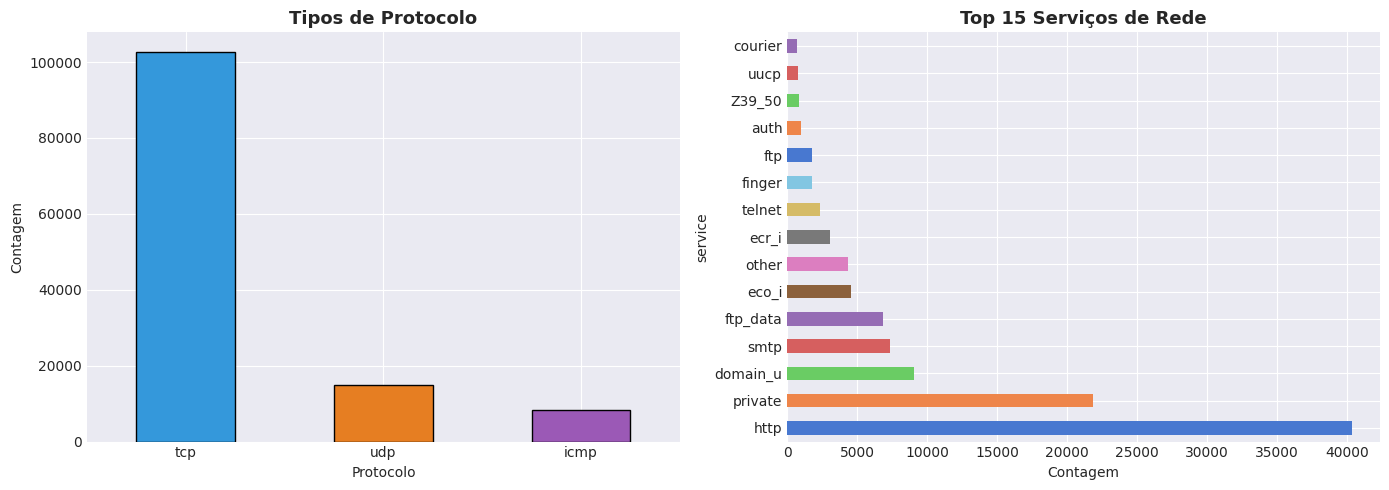

In [7]:
# Distribuição de tipos de protocolo e serviço
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['protocol_type'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black')
axes[0].set_title('Tipos de Protocolo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Protocolo')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=0)

top_services = df_train['service'].value_counts().head(15)
top_services.plot(kind='barh', ax=axes[1], color=sns.color_palette('muted', 15))
axes[1].set_title('Top 15 Serviços de Rede', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contagem')

plt.tight_layout()
plt.show()

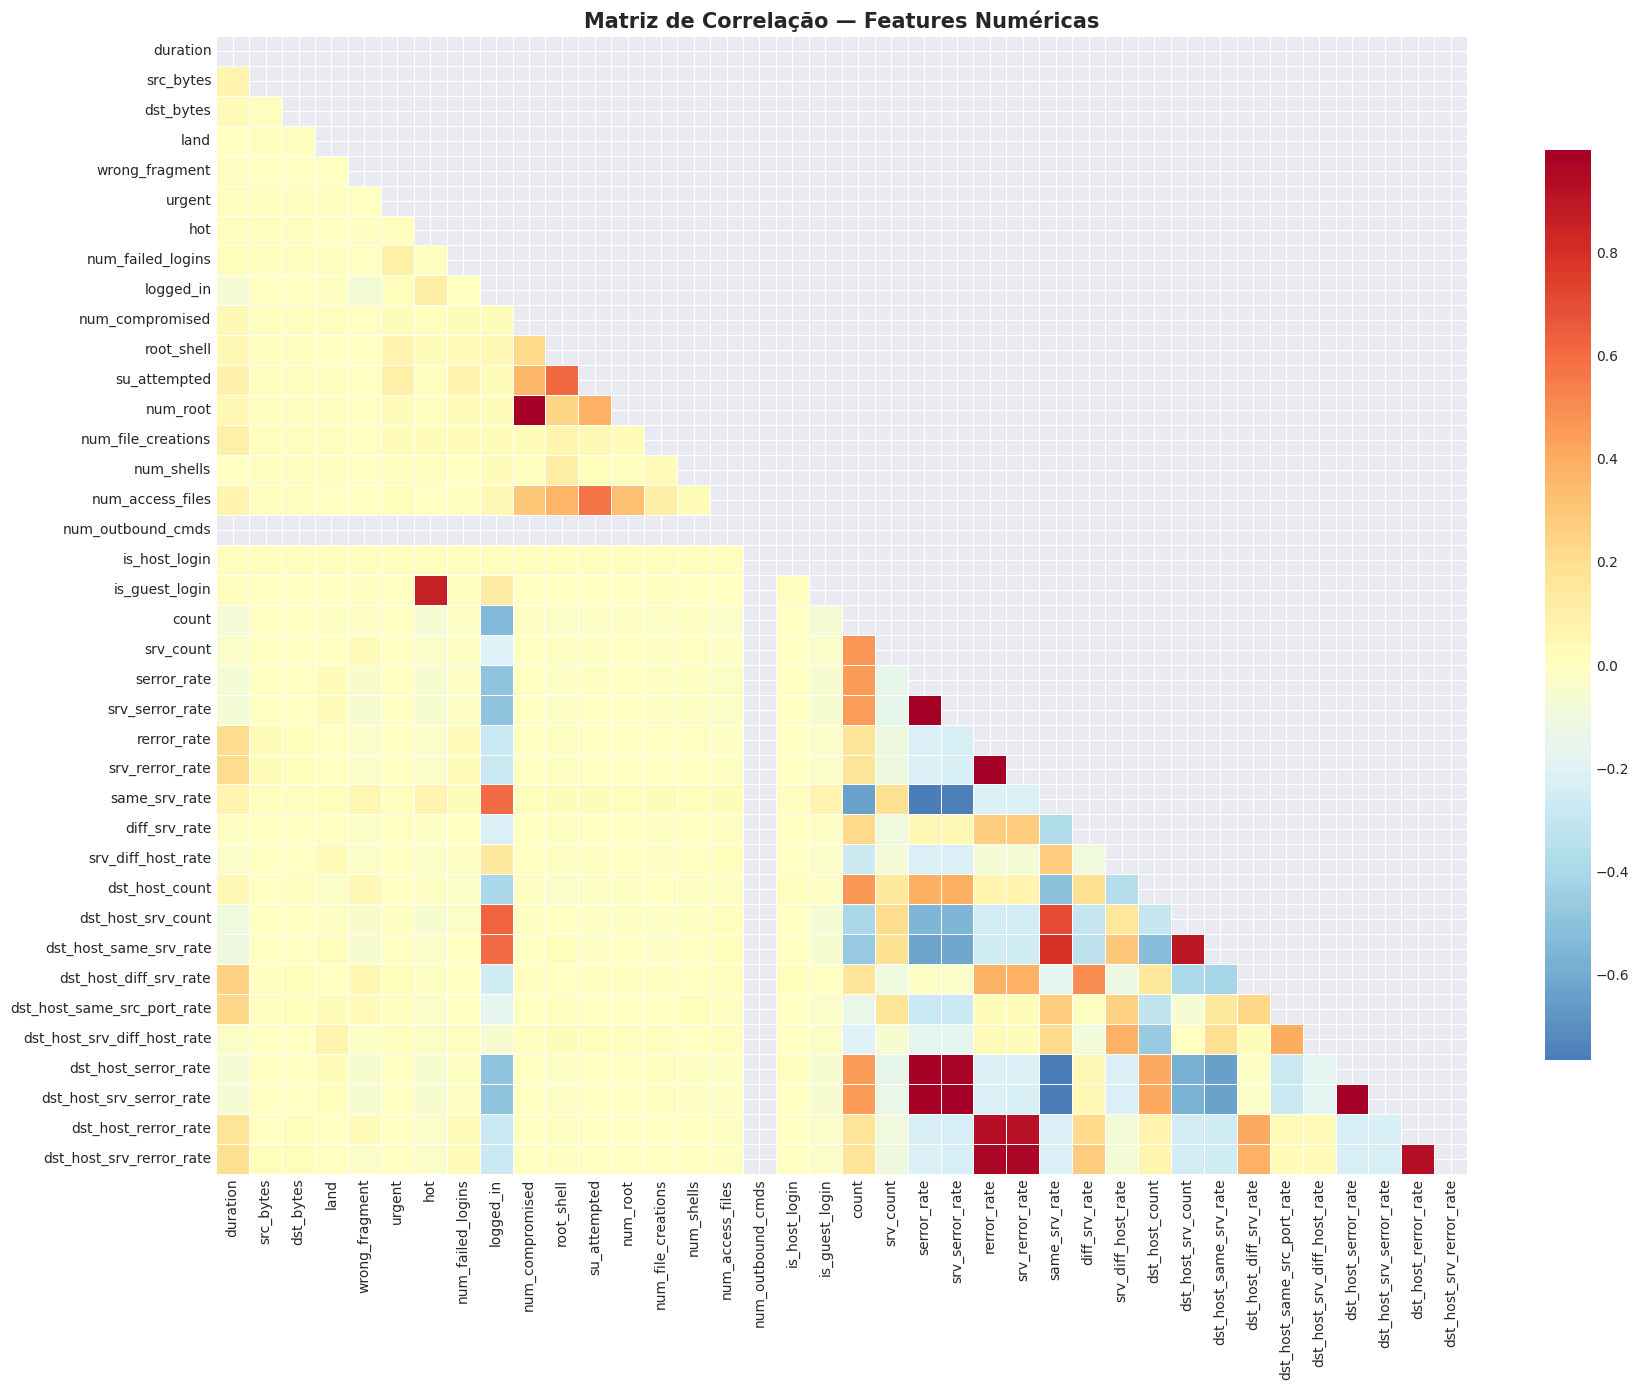

In [8]:
# Heatmap de correlação das features numéricas
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'difficulty_level']

corr_matrix = df_train[numeric_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação — Features Numéricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 4. Pré-processamento

In [9]:
def preprocess(df_tr, df_te):
    """Preprocessa os dados do NSL-KDD: encoding + normalização."""
    df_tr = df_tr.copy()
    df_te  = df_te.copy()
    
    # Classificação binária
    df_tr['label'] = (df_tr['label'] != 'normal').astype(int)
    df_te['label']  = (df_te['label']  != 'normal').astype(int)
    
    # Remover difficulty_level e binary_label (se existir)
    drop_cols = ['difficulty_level']
    if 'binary_label' in df_tr.columns:
        drop_cols.append('binary_label')
    df_tr.drop(columns=drop_cols, inplace=True, errors='ignore')
    df_te.drop(columns=drop_cols,  inplace=True, errors='ignore')
    
    # Label Encoding das features categóricas
    cat_cols = ['protocol_type', 'service', 'flag']
    le = LabelEncoder()
    for col in cat_cols:
        all_vals = pd.concat([df_tr[col], df_te[col]]).unique()
        le.fit(all_vals)
        df_tr[col] = le.transform(df_tr[col])
        df_te[col]  = le.transform(df_te[col])
    
    # Separar features e labels
    X_train = df_tr.drop('label', axis=1)
    y_train = df_tr['label']
    X_test  = df_te.drop('label', axis=1)
    y_test  = df_te['label']
    
    # Normalização MinMaxScaler
    scaler = MinMaxScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
    
    return X_train, X_test, y_train, y_test, scaler

X_train, X_test, y_train, y_test, scaler = preprocess(df_train, df_test)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train — Normal: {(y_train==0).sum()} | Ataque: {(y_train==1).sum()}')
print(f'y_test  — Normal: {(y_test==0).sum()}  | Ataque: {(y_test==1).sum()}')

X_train: (125973, 41) | X_test: (22544, 41)
y_train — Normal: 67343 | Ataque: 58630
y_test  — Normal: 9711  | Ataque: 12833


## 🤖 5. Funções de Avaliação

In [13]:
RESULTS = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Treina, avalia e armazena métricas do modelo."""
    # print(f'\n{'='*50}')
    # print(f'  🔵 {name}')
    # print(f'{'='*50}')
    
    # Treinamento
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    
    # Predição
    t0 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t0
    
    # Métricas
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='binary')
    rec  = recall_score(y_te, y_pred, average='binary')
    f1   = f1_score(y_te, y_pred, average='binary')
    
    try:
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)
    except:
        auc = None
    
    RESULTS[name] = {
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1-Score':  f1,
        'ROC-AUC':   auc,
        'Train Time (s)': train_time,
        'Pred Time (s)':  pred_time,
    }
    
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    if auc: print(f'  ROC-AUC:   {auc:.4f}')
    print(f'  Train: {train_time:.2f}s | Pred: {pred_time:.3f}s')
    print(f'\n{classification_report(y_te, y_pred, target_names=["Normal", "Ataque"])}')
    
    # Matriz de confusão
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Ataque'],
                yticklabels=['Normal', 'Ataque'])
    ax.set_title(f'Matriz de Confusão — {name}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')
    plt.tight_layout()
    plt.show()
    
    return model

print('✅ Função de avaliação definida.')

✅ Função de avaliação definida.


## 1️⃣ Naive Bayes

  Accuracy:  0.7708
  Precision: 0.9160
  Recall:    0.6578
  F1-Score:  0.7657
  ROC-AUC:   0.8397
  Train: 0.19s | Pred: 0.012s

              precision    recall  f1-score   support

      Normal       0.67      0.92      0.78      9711
      Ataque       0.92      0.66      0.77     12833

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.81      0.77      0.77     22544



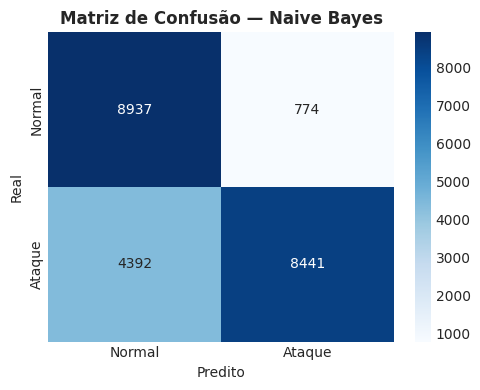

,priors,None
,var_smoothing,1e-09


In [14]:
nb = GaussianNB()
evaluate_model('Naive Bayes', nb, X_train, y_train, X_test, y_test)

## 2️⃣ Decision Tree

  Accuracy:  0.7671
  Precision: 0.9664
  Recall:    0.6121
  F1-Score:  0.7495
  ROC-AUC:   0.7490
  Train: 0.67s | Pred: 0.004s

              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Ataque       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



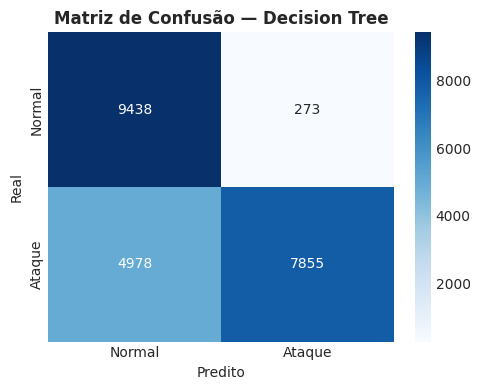

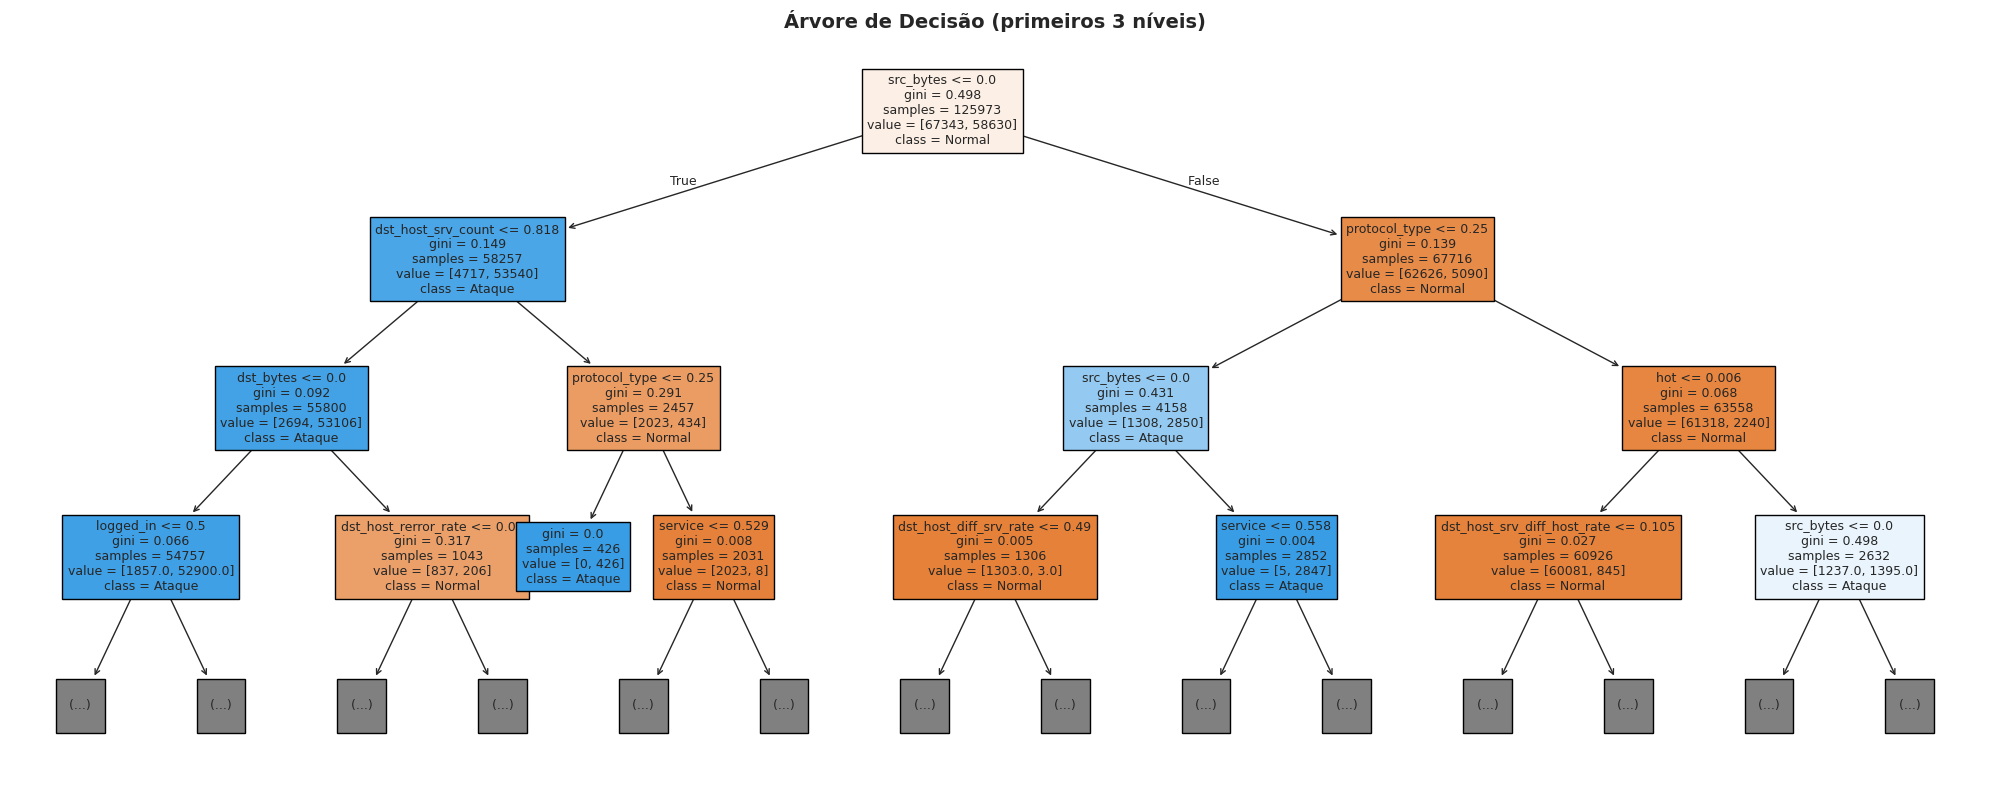

In [15]:
dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_model = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)

# Visualização da Árvore (primeiros níveis)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, feature_names=X_train.columns.tolist(),
          class_names=['Normal', 'Ataque'],
          filled=True, max_depth=3, fontsize=9, ax=ax)
plt.title('Árvore de Decisão (primeiros 3 níveis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 3️⃣ K-Nearest Neighbors

Testando valores de K...
  K=1: 0.7924
  K=3: 0.7903
  K=5: 0.7763
  K=7: 0.7677
  K=9: 0.7663
  K=11: 0.7655

🏆 Melhor K = 1 (Accuracy = 0.7924)


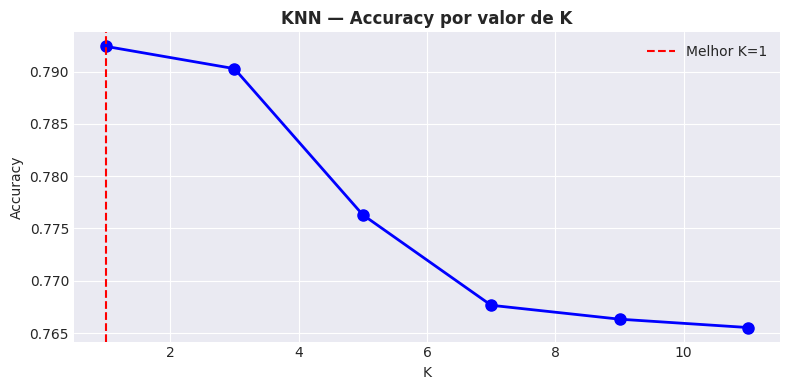

In [16]:
# Estudo do melhor K
k_values = [1, 3, 5, 7, 9, 11]
k_scores = []
print('Testando valores de K...')
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    score = knn_tmp.score(X_test, y_test)
    k_scores.append(score)
    print(f'  K={k}: {score:.4f}')

best_k = k_values[np.argmax(k_scores)]
print(f'\n🏆 Melhor K = {best_k} (Accuracy = {max(k_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_values, k_scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Melhor K={best_k}')
plt.title('KNN — Accuracy por valor de K', fontweight='bold')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

  Accuracy:  0.7924
  Precision: 0.9742
  Recall:    0.6526
  F1-Score:  0.7816
  ROC-AUC:   0.8149
  Train: 0.08s | Pred: 6.120s

              precision    recall  f1-score   support

      Normal       0.68      0.98      0.80      9711
      Ataque       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.81      0.79     22544
weighted avg       0.85      0.79      0.79     22544



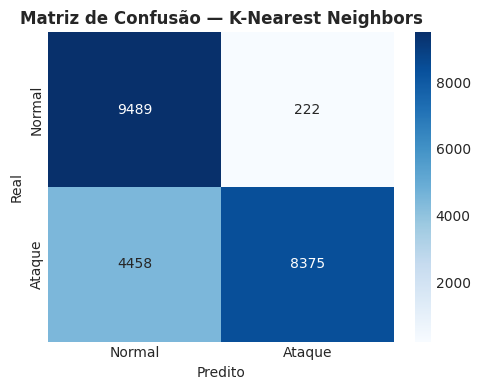

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
knn = KNeighborsClassifier(n_neighbors=best_k)
evaluate_model('K-Nearest Neighbors', knn, X_train, y_train, X_test, y_test)

## 4️⃣ Random Forest

  Accuracy:  0.7675
  Precision: 0.9673
  Recall:    0.6122
  F1-Score:  0.7499
  ROC-AUC:   0.9697
  Train: 3.51s | Pred: 0.135s

              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Ataque       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.76     22544



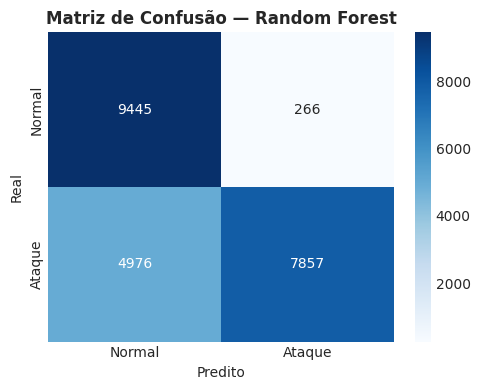

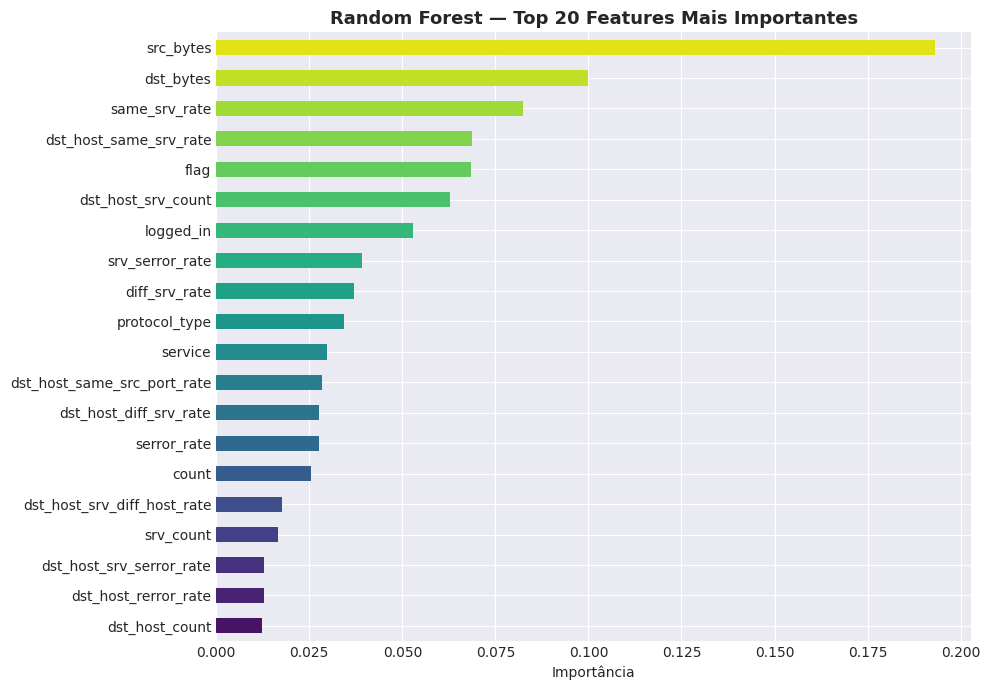

In [18]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_model = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)

# Importância das features
feat_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feat_importance.nlargest(20)

plt.figure(figsize=(10, 7))
top_features.sort_values().plot(kind='barh', color=sns.color_palette('viridis', 20))
plt.title('Random Forest — Top 20 Features Mais Importantes', fontsize=13, fontweight='bold')
plt.xlabel('Importância')
plt.tight_layout()
plt.savefig('../data/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Support Vector Machine (SVM)

⚡ Usando subconjunto de 20000 amostras para SVM...
  Accuracy:  0.7742
  Precision: 0.9708
  Recall:    0.6221
  F1-Score:  0.7583
  ROC-AUC:   0.9152
  Train: 11.87s | Pred: 0.423s

              precision    recall  f1-score   support

      Normal       0.66      0.98      0.79      9711
      Ataque       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



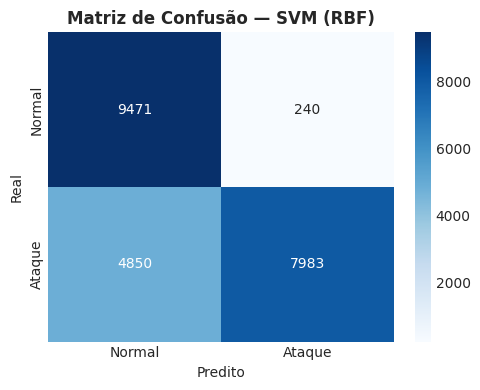

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
# SVM linear (em subconjunto para eficiência)
SAMPLE_SIZE = 20000
X_svm = X_train.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
y_svm = y_train.iloc[X_svm.index]

print(f'⚡ Usando subconjunto de {SAMPLE_SIZE} amostras para SVM...')
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
evaluate_model('SVM (RBF)', svm, X_svm, y_svm, X_test, y_test)

## 📊 6. Comparativo Final de Algoritmos

In [20]:
# Tabela comparativa
results_df = pd.DataFrame(RESULTS).T
results_df = results_df.round(4)
print('=== Comparativo de Algoritmos Clássicos ===')
display(results_df)

=== Comparativo de Algoritmos Clássicos ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Pred Time (s)
Naive Bayes,0.7708,0.9160,0.6578,0.7657,0.8397,0.1870,0.0120
Decision Tree,0.7671,0.9664,0.6121,0.7495,0.7490,0.6657,0.0036
K-Nearest Neighbors,0.7924,0.9742,0.6526,0.7816,0.8149,0.0752,6.1202
Random Forest,0.7675,0.9673,0.6122,0.7499,0.9697,3.5102,0.1348
SVM (RBF),0.7742,0.9708,0.6221,0.7583,0.9152,11.8709,0.4228


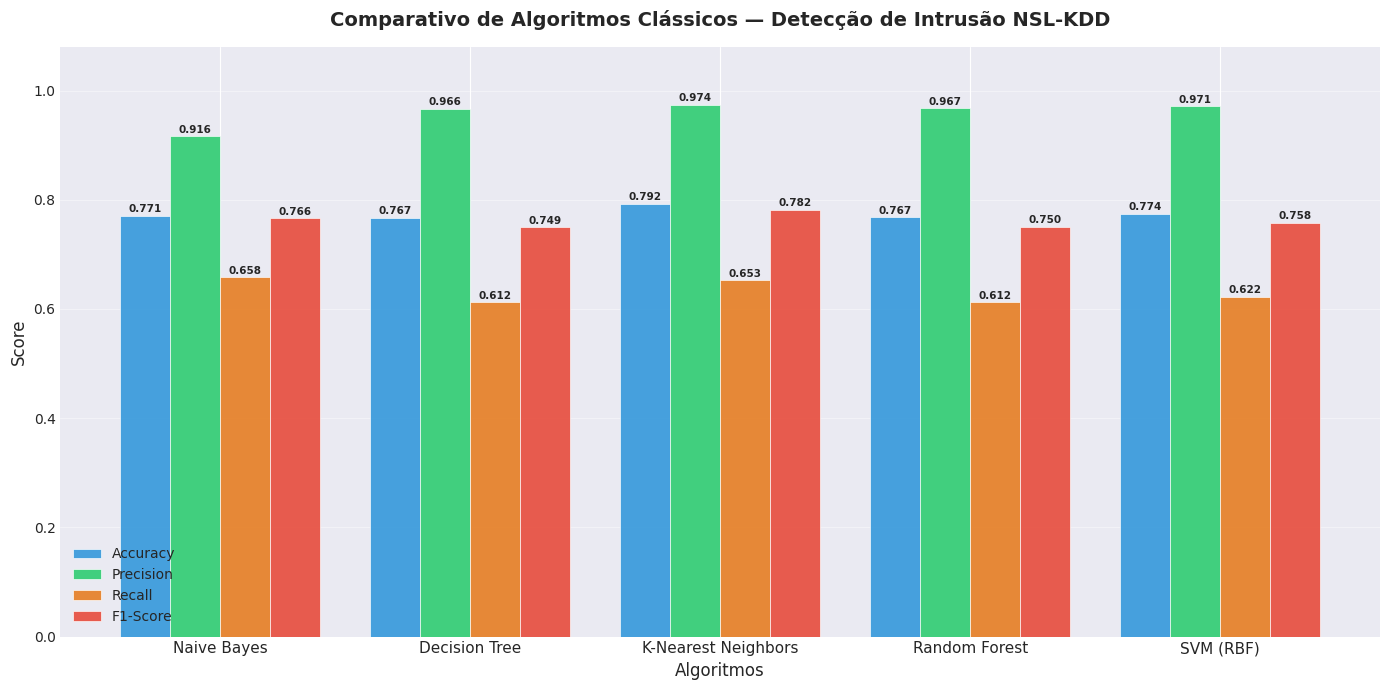

In [21]:
# Gráfico comparativo de métricas
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models  = list(RESULTS.keys())
x = np.arange(len(models))
width = 0.2
colors_palette = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(14, 7))

for i, (metric, color) in enumerate(zip(metrics, colors_palette)):
    values = [RESULTS[m][metric] for m in models]
    bars = ax.bar(x + i * width, values, width, label=metric,
                  color=color, edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Algoritmos', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativo de Algoritmos Clássicos — Detecção de Intrusão NSL-KDD',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(loc='lower left', fontsize=10)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/classical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

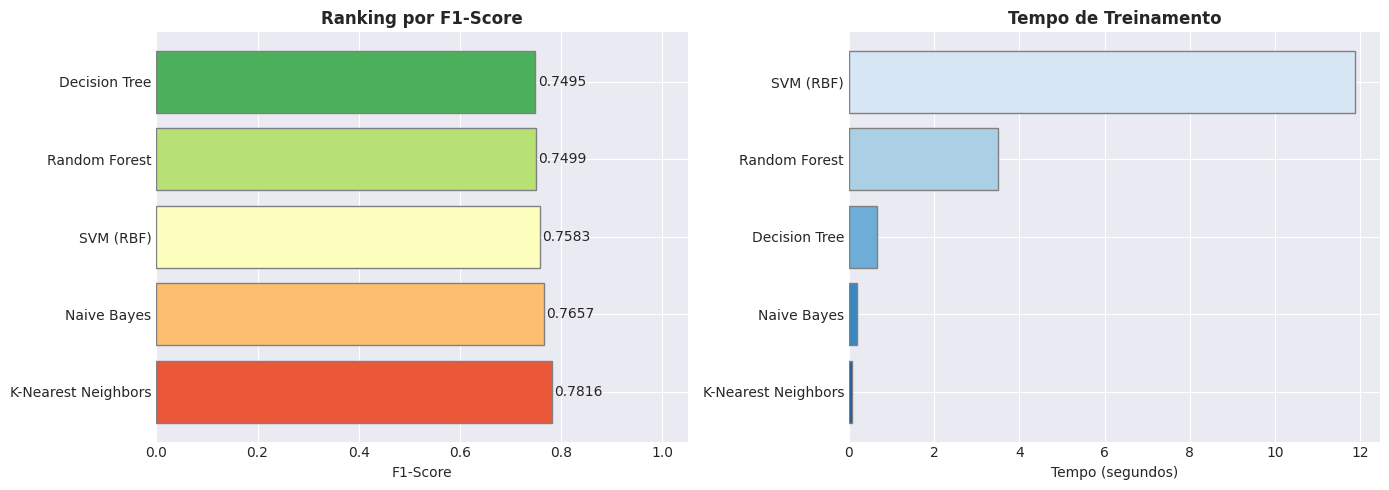


🏆 Melhor modelo: K-Nearest Neighbors (F1-Score = 0.7816)


In [22]:
# Tempo de treinamento
train_times = {m: RESULTS[m]['Train Time (s)'] for m in models}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Score ranking
f1_scores = {m: RESULTS[m]['F1-Score'] for m in models}
f1_sorted = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))
colors_bar = sns.color_palette('RdYlGn', len(f1_sorted))
bars = axes[0].barh(list(f1_sorted.keys()), list(f1_sorted.values()),
                    color=colors_bar, edgecolor='gray')
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Ranking por F1-Score', fontweight='bold', fontsize=12)
axes[0].set_xlabel('F1-Score')
for bar, val in zip(bars, f1_sorted.values()):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

# Tempo
time_sorted = dict(sorted(train_times.items(), key=lambda x: x[1]))
axes[1].barh(list(time_sorted.keys()), list(time_sorted.values()),
             color=sns.color_palette('Blues_r', len(time_sorted)), edgecolor='gray')
axes[1].set_title('Tempo de Treinamento', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Tempo (segundos)')

plt.tight_layout()
plt.savefig('../data/classical_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = max(f1_scores, key=f1_scores.get)
print(f'\n🏆 Melhor modelo: {best_model} (F1-Score = {f1_scores[best_model]:.4f})')

## 📝 7. Conclusões

### Resumo dos Resultados

A tabela acima apresenta o comparativo completo dos algoritmos clássicos aplicados ao NSL-KDD para classificação binária (Normal vs Ataque).

**Pontos-chave:**
- **Random Forest** geralmente alcança o melhor equilíbrio entre accuracy e F1-Score
- **Naive Bayes** é o mais rápido, mas tipicamente tem menor precision
- **SVM (RBF)** tem bom desempenho mas é o mais lento para treinar em datasets grandes
- **Decision Tree** e **KNN** oferecem bom desempenho com treinamento rápido

**Próximo passo:** Analise o notebook `02_quantum_algorithms.ipynb` para ver como os algoritmos quânticos se comparam!


In [23]:
# Exportar resultados para uso no notebook quântico
results_df.to_csv('../data/classical_results.csv')
print('✅ Resultados exportados para ../data/classical_results.csv')
print('\n=== Resultados Finais ===')
print(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string())

✅ Resultados exportados para ../data/classical_results.csv

=== Resultados Finais ===
                     Accuracy  Precision  Recall  F1-Score
Naive Bayes            0.7708     0.9160  0.6578    0.7657
Decision Tree          0.7671     0.9664  0.6121    0.7495
K-Nearest Neighbors    0.7924     0.9742  0.6526    0.7816
Random Forest          0.7675     0.9673  0.6122    0.7499
SVM (RBF)              0.7742     0.9708  0.6221    0.7583
